# COVID-19 Global Trends Analysis (Time Series & Geospatial)

**Author:** Ibrahim    
**Environment:** Google Colab / Python 3

## Overview
This notebook analyses the global trajectory of the COVID-19 pandemic using public data from Our World in Data. It covers trends in confirmed cases, deaths, mortality rates, and per‑capita metrics across countries and continents. The analysis includes 10 professional visualisations, from time series to geospatial maps.

## Dataset
- **Source:** Our World in Data – COVID-19 dataset
- **Rows:** ~100,000 daily observations
- **Columns:** date, location, total_cases, new_cases, total_deaths, new_deaths, population, continent, etc.

## Key Analysis Steps
1. Data loading and filtering (latest date, valid countries)
2. Global daily time series
3. Country‑level comparisons (top affected)
4. Mortality rate and per‑capita metrics
5. Regional analysis by continent
6. Rolling averages to smooth noise
7. Interactive geospatial map (optional)

## Requirements
- pandas, matplotlib, seaborn, plotly (for choropleth)

---

**© 2026 Ibrahim – COVID-19 global trends.**

### Install & Imports

In [1]:
!pip install -q pandas matplotlib seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [2]:
df = pd.read_csv('/content/owid-covid-data.csv')

print("Dataset shape:", df.shape)
print("Available columns:", df.columns.tolist()[:20])  # first 20
print("Date range:", df['date'].min(), "to", df['date'].max())

Dataset shape: (429435, 67)
Available columns: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients']
Date range: 2020-01-01 to 2024-08-14


In [14]:
# Debug: Check what data is actually in 'latest'
print("Latest data shape:", latest.shape)
print("Columns available:", latest.columns.tolist())
print("Data types:", latest[['total_cases', 'total_deaths', 'location']].dtypes)
print("\nFirst few rows of total_cases:\n", latest['total_cases'].head(10))
print("\nAre there NaN values? ", latest['total_cases'].isna().sum())
print("\nAre there zeros? ", (latest['total_cases'] == 0).sum())
print("\nLargest total_cases value (if any):", latest['total_cases'].max())

Latest data shape: (2, 67)
Columns available: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 

In [15]:
# Ensure we have continuous date data
# First, make sure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'])

# Filter to rows where continent is not null AND date is the maximum date in the whole dataset
# (not just from df_continent, which may have fewer rows)
global_max_date = df['date'].max()
print(f"Global max date: {global_max_date}")

# Get all rows at that date, but only those with continent (excluding 'World' etc.)
latest = df[(df['date'] == global_max_date) & (df['continent'].notna())].copy()
print(f"Latest shape after proper filter: {latest.shape}")

# Verify we have data
print(f"Total cases non-NaN count: {latest['total_cases'].notna().sum()}")
print(f"Sample countries with total_cases: {latest[latest['total_cases'].notna()]['location'].head(10).tolist()}")

Global max date: 2024-08-14 00:00:00
Latest shape after proper filter: (2, 67)
Total cases non-NaN count: 0
Sample countries with total_cases: []


### Data Cleaning & Filtering

In [16]:
# After loading df, ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'])

# Filter for countries (not continents, not 'World')
countries_only = df[df['continent'].notna()].copy()

# For each country, get the most recent row where total_cases is not null
latest_per_country = countries_only.sort_values('date').groupby('location').last().reset_index()
# But that picks the last row per country regardless of nulls. Better: dropna first
# Use groupby to get the last non-null total_cases row per country
def last_non_null(group):
    return group.dropna(subset=['total_cases']).iloc[-1] if len(group.dropna(subset=['total_cases'])) > 0 else None

latest = countries_only.groupby('location').apply(lambda x: x[x['total_cases'].notna()].sort_values('date').iloc[-1] if len(x[x['total_cases'].notna()]) > 0 else None)
latest = latest.reset_index(drop=True)

print(f"Latest data shape: {latest.shape}")
print("Sample countries:", latest['location'].head(5).tolist())
print("Total cases non-NaN count:", latest['total_cases'].notna().sum())

Latest data shape: (243, 67)
Sample countries: ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra']
Total cases non-NaN count: 234


### Global Daily New Cases

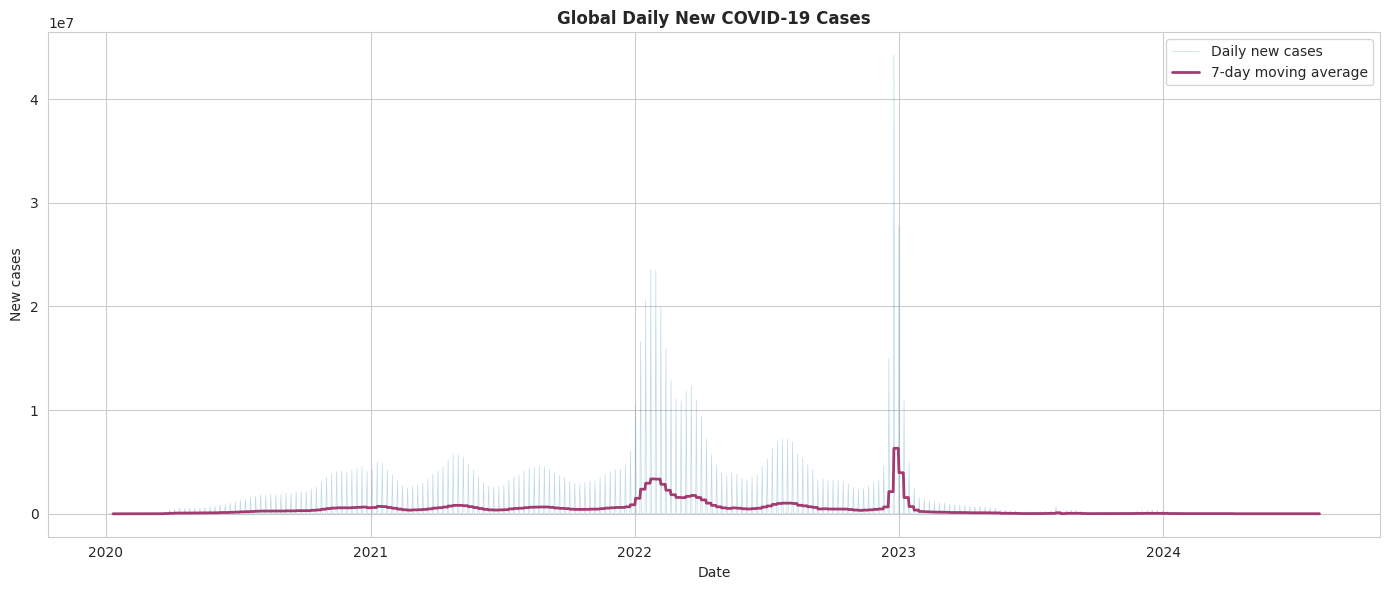

In [17]:
global_daily = df[df['location'] == 'World'].copy()
global_daily['new_cases_smoothed'] = global_daily['new_cases'].rolling(7).mean()

plt.figure(figsize=(14, 6))
plt.plot(global_daily['date'], global_daily['new_cases'], alpha=0.3, linewidth=0.5, color='#2E86AB', label='Daily new cases')
plt.plot(global_daily['date'], global_daily['new_cases_smoothed'], color='#A23B72', linewidth=2, label='7‑day moving average')
plt.title('Global Daily New COVID-19 Cases', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('New cases')
plt.legend()
plt.tight_layout()
plt.show()

### Global Daily New Deaths

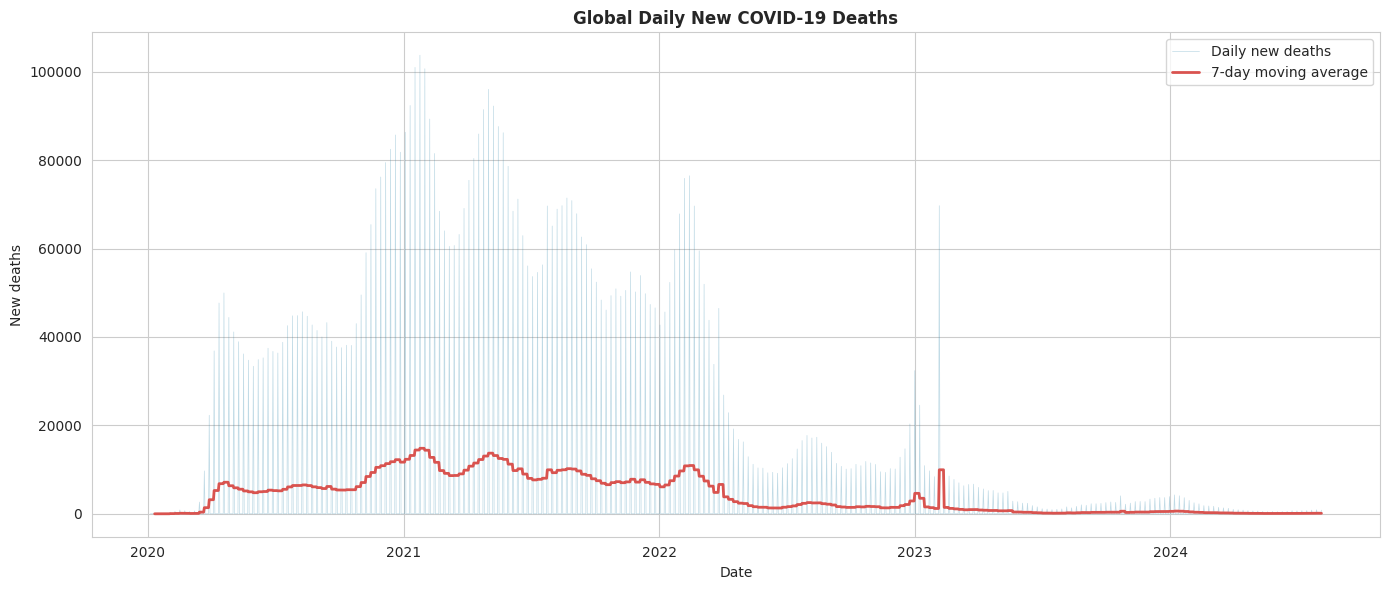

In [18]:
global_daily['new_deaths_smoothed'] = global_daily['new_deaths'].rolling(7).mean()

plt.figure(figsize=(14, 6))
plt.plot(global_daily['date'], global_daily['new_deaths'], alpha=0.3, linewidth=0.5, color='#2E86AB', label='Daily new deaths')
plt.plot(global_daily['date'], global_daily['new_deaths_smoothed'], color='#D9534F', linewidth=2, label='7‑day moving average')
plt.title('Global Daily New COVID-19 Deaths', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('New deaths')
plt.legend()
plt.tight_layout()
plt.show()

### Top 10 Countries by Total Cases

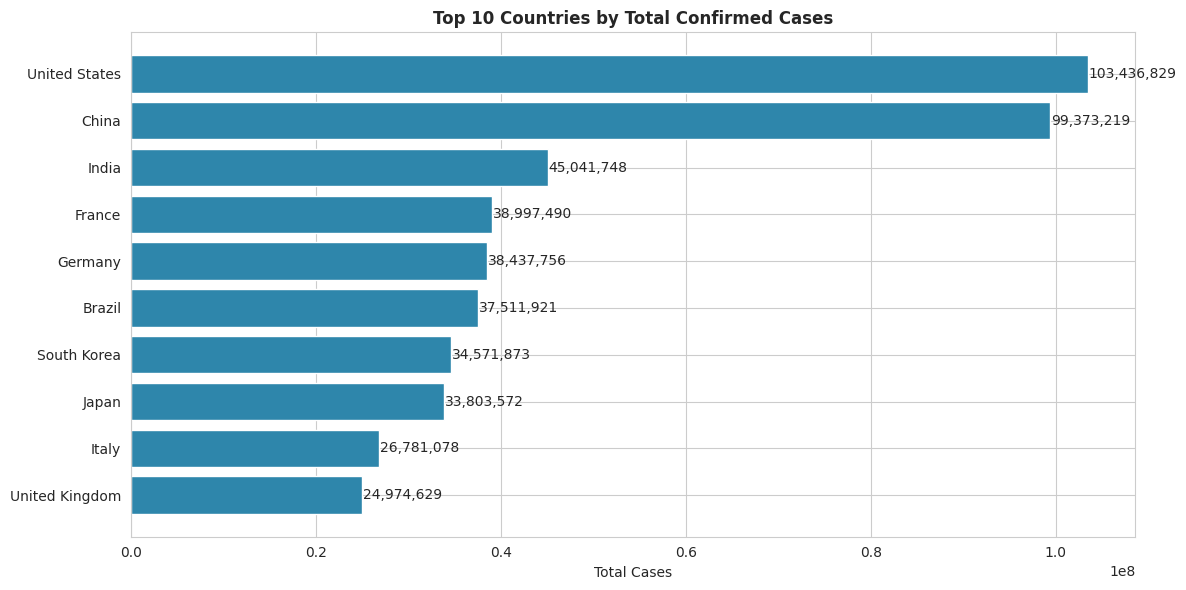

In [19]:
top_cases = latest.nlargest(10, 'total_cases')[['location', 'total_cases']]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_cases['location'][::-1], top_cases['total_cases'][::-1], color='#2E86AB')
plt.xlabel('Total Cases')
plt.title('Top 10 Countries by Total Confirmed Cases', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    if not pd.isna(width) and width > 0:
        plt.text(width + 100000, bar.get_y() + bar.get_height()/2, f'{int(width):,}', va='center')
plt.tight_layout()
plt.show()

### Top 10 Countries by Total Deaths

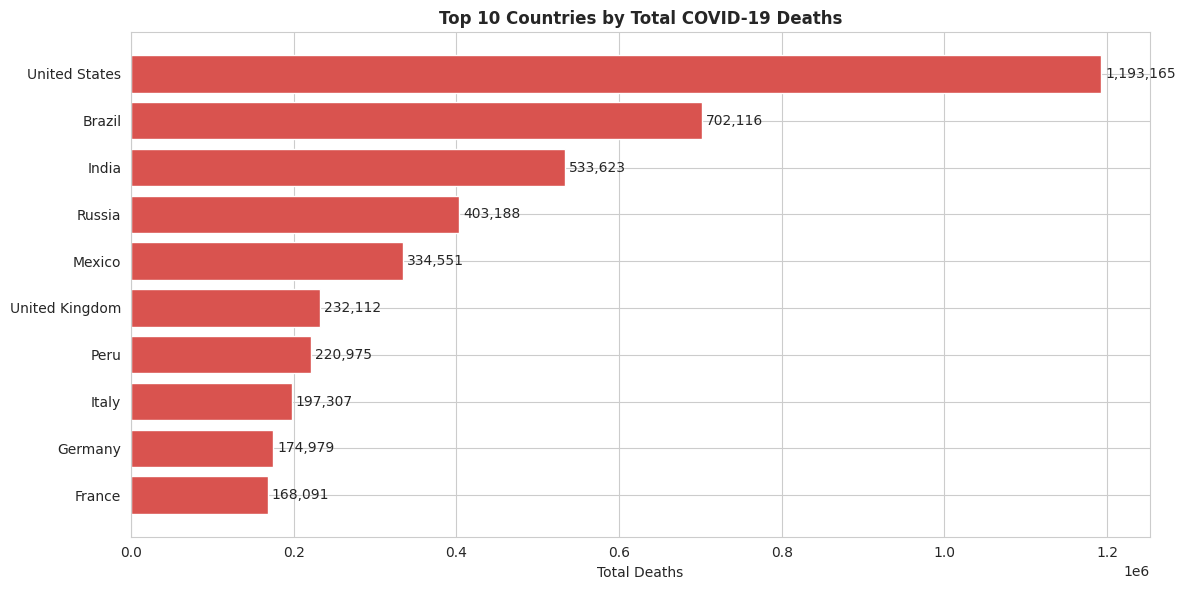

In [20]:
top_deaths = latest.nlargest(10, 'total_deaths')[['location', 'total_deaths']]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_deaths['location'][::-1], top_deaths['total_deaths'][::-1], color='#D9534F')
plt.xlabel('Total Deaths')
plt.title('Top 10 Countries by Total COVID-19 Deaths', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    if not pd.isna(width) and width > 0:
        plt.text(width + 5000, bar.get_y() + bar.get_height()/2, f'{int(width):,}', va='center')
plt.tight_layout()
plt.show()

### Daily New Cases Stacked by Continent

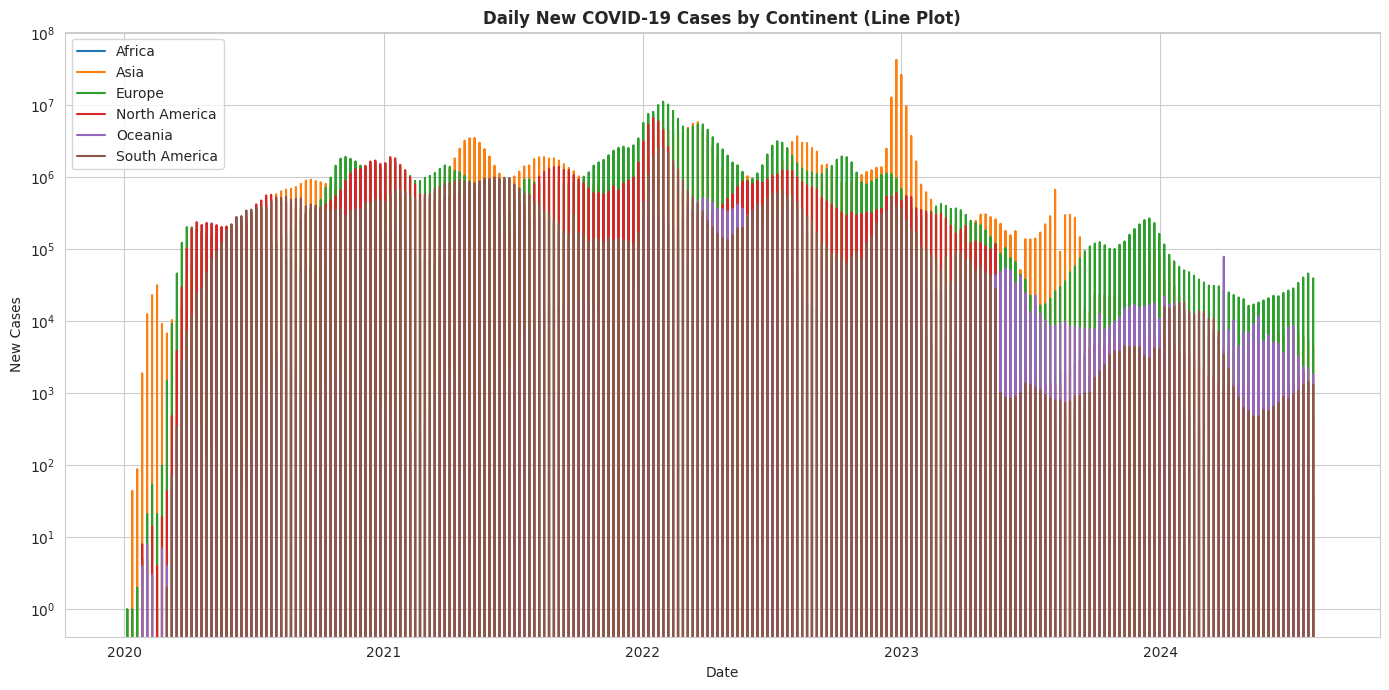

In [30]:
# Plot each continent as a separate line (better for comparing trends)
plt.figure(figsize=(14, 7))
for cont in pivot_continent.columns:
    plt.plot(pivot_continent.index, pivot_continent[cont], label=cont, linewidth=1.5)
plt.title('Daily New COVID-19 Cases by Continent (Line Plot)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.legend(loc='upper left')
plt.yscale('log')  # Log scale to see all continents clearly
plt.tight_layout()
plt.show()

### Mortality Rate Bubble Chart

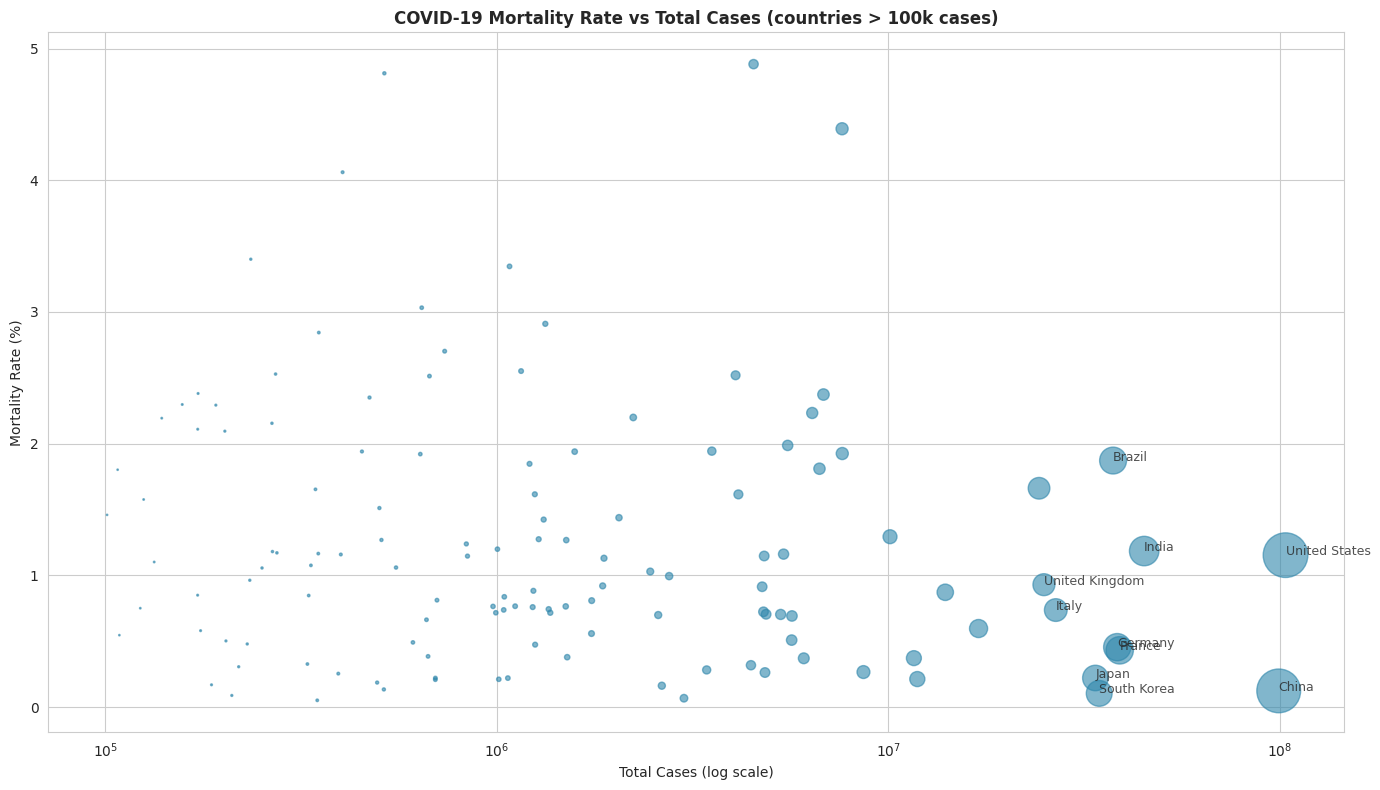

In [32]:
# Calculate mortality rate (total_deaths / total_cases) and filter significant cases
latest_mortality = latest[latest['total_cases'] > 100000].copy()
latest_mortality['mortality_rate'] = (latest_mortality['total_deaths'] / latest_mortality['total_cases']) * 100

plt.figure(figsize=(14, 8))
scatter = plt.scatter(latest_mortality['total_cases'], latest_mortality['mortality_rate'],
                      s=latest_mortality['total_cases']/100000, alpha=0.6, c='#2E86AB')
plt.xscale('log')
plt.xlabel('Total Cases (log scale)')
plt.ylabel('Mortality Rate (%)')
plt.title('COVID‑19 Mortality Rate vs Total Cases (countries > 100k cases)', fontweight='bold')
for _, row in latest_mortality.nlargest(10, 'total_cases').iterrows():
    plt.annotate(row['location'], (row['total_cases'], row['mortality_rate']), fontsize=9, alpha=0.8)
plt.tight_layout()
plt.show()

### Cases per Million Population (Top 20)

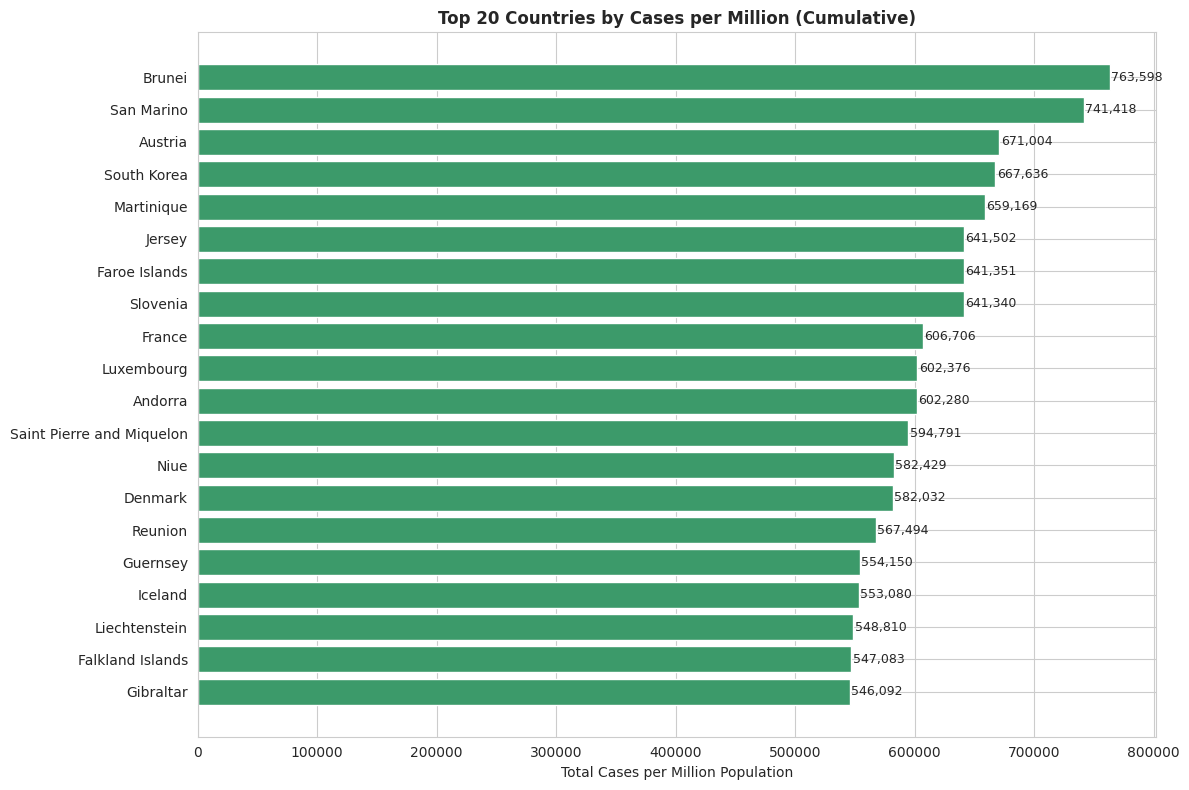

In [33]:
top_cases_per_million = latest.nlargest(20, 'total_cases_per_million')[['location', 'total_cases_per_million']]

plt.figure(figsize=(12, 8))
bars = plt.barh(top_cases_per_million['location'][::-1], top_cases_per_million['total_cases_per_million'][::-1], color='#3C9A6A')
plt.xlabel('Total Cases per Million Population')
plt.title('Top 20 Countries by Cases per Million (Cumulative)', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1000, bar.get_y() + bar.get_height()/2, f'{int(width):,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Heatmap of Weekly New Cases (Selected Countries)

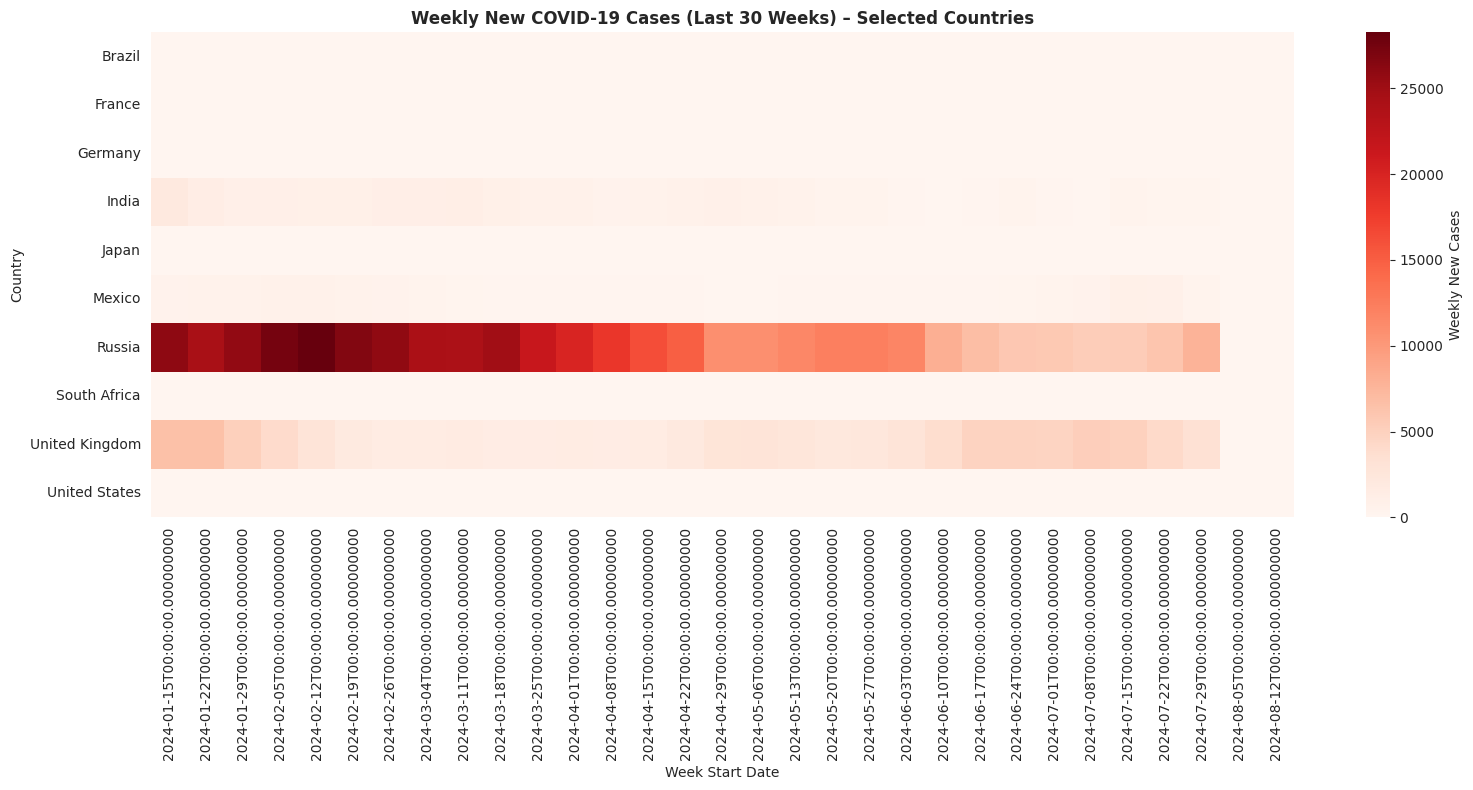

In [35]:
# Select 10 major countries
selected = ['United States', 'Brazil', 'India', 'United Kingdom', 'France', 'Germany', 'Japan', 'South Africa', 'Mexico', 'Russia']
selected_df = df_continent[df_continent['location'].isin(selected)].copy()

# Add week and year columns
selected_df['week'] = selected_df['date'].dt.isocalendar().week
selected_df['year'] = selected_df['date'].dt.year

# Aggregate weekly cases
weekly_cases = selected_df.groupby(['location', 'year', 'week'])['new_cases'].sum().reset_index()

# Create a date column for the Monday of each week (for filtering)
weekly_cases['week_date'] = pd.to_datetime(weekly_cases['year'].astype(str) + '-W' + weekly_cases['week'].astype(str) + '-1', format='%G-W%V-%u')

# Filter to last 30 weeks
max_week_date = weekly_cases['week_date'].max()
start_week_date = max_week_date - pd.Timedelta(days=210)
recent_weekly = weekly_cases[weekly_cases['week_date'] >= start_week_date]

# Create pivot table for heatmap
recent_weekly_pivot = recent_weekly.pivot(index='location', columns='week_date', values='new_cases')

# Fill NaN with 0 (for weeks with no data)
recent_weekly_pivot = recent_weekly_pivot.fillna(0)

# Plot heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(recent_weekly_pivot, cmap='Reds', annot=False, cbar_kws={'label': 'Weekly New Cases'})
plt.title('Weekly New COVID-19 Cases (Last 30 Weeks) – Selected Countries', fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### 7‑Day Rolling Average – Major Countries

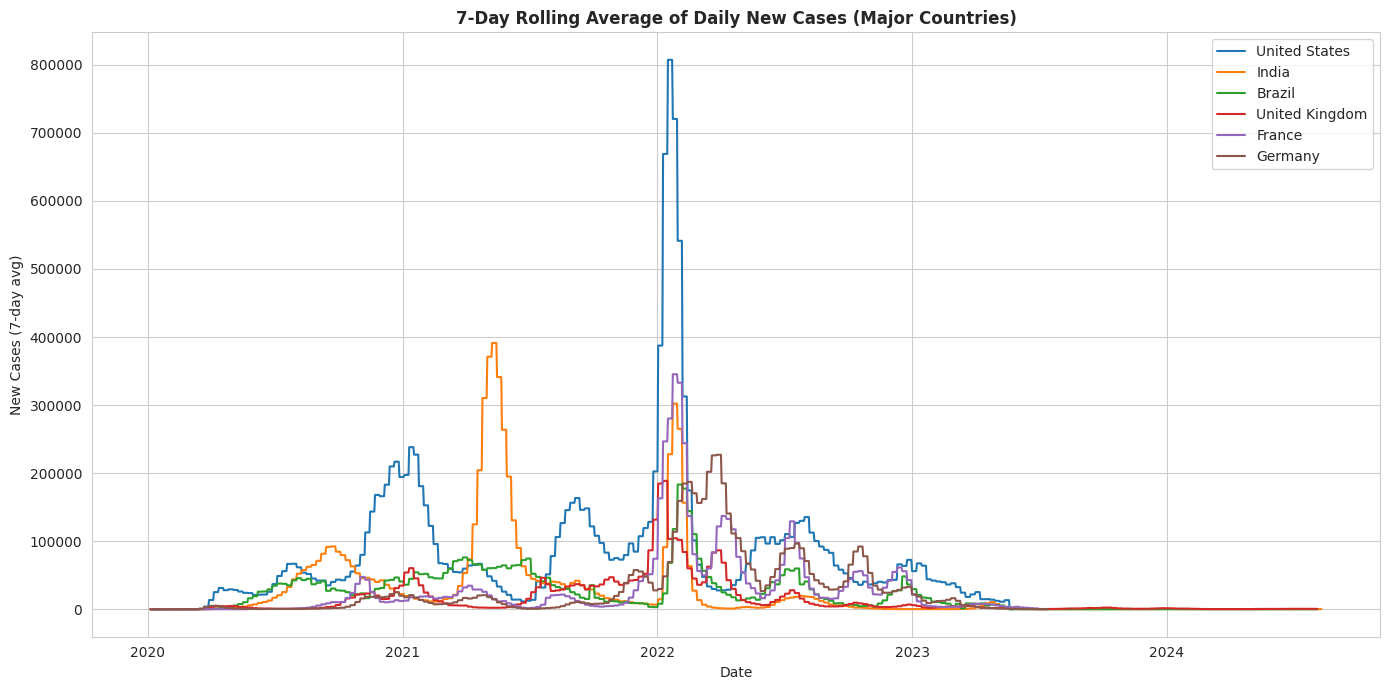

In [36]:
major_countries = ['United States', 'India', 'Brazil', 'United Kingdom', 'France', 'Germany']
major_filtered = df_continent[df_continent['location'].isin(major_countries)].copy()
major_filtered['new_cases_7d'] = major_filtered.groupby('location')['new_cases'].transform(lambda x: x.rolling(7, min_periods=1).mean())

plt.figure(figsize=(14, 7))
for country in major_countries:
    country_data = major_filtered[major_filtered['location'] == country]
    plt.plot(country_data['date'], country_data['new_cases_7d'], label=country)
plt.title('7‑Day Rolling Average of Daily New Cases (Major Countries)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('New Cases (7‑day avg)')
plt.legend()
plt.tight_layout()
plt.show()

### Choropleth Map (Plotly)

In [37]:
# Use the latest data for all countries (including those without continent filter but that have coordinates)
world_latest = df[df['date'] == latest_date].dropna(subset=['iso_code'])
fig = px.choropleth(world_latest,
                    locations="iso_code",
                    color="total_cases_per_million",
                    hover_name="location",
                    color_continuous_scale="OrRd",
                    title="Total COVID-19 Cases per Million Population (Latest Data)")
fig.update_layout(title_font=dict(size=16, weight='bold'), coloraxis_colorbar=dict(title="Cases per Million"))
fig.show()

### Key Insights Summary

In [38]:
print(" Key Insights from COVID-19 Global Analysis")
print(f" Data period: {df['date'].min().date()} to {latest_date.date()}")
print(f" Countries/regions analyzed: {latest['location'].nunique()}")
top_country = latest.nlargest(1, 'total_cases')['location'].iloc[0]
print(f" Highest total cases: {top_country}")
highest_per_capita = latest.nlargest(1, 'total_cases_per_million')['location'].iloc[0]
print(f" Highest cases per million: {highest_per_capita}")
print(f" Global peak daily cases (7‑day avg): {global_daily['new_cases_smoothed'].max():,.0f} on {global_daily.loc[global_daily['new_cases_smoothed'].idxmax(), 'date'].date()}")

 Key Insights from COVID-19 Global Analysis
 Data period: 2020-01-01 to 2024-08-14
 Countries/regions analyzed: 234
 Highest total cases: United States
 Highest cases per million: Brunei
 Global peak daily cases (7‑day avg): 6,319,461 on 2022-12-25


### Final Summary

In [39]:
print("COVID‑19 Global Trends Analysis - COMPLETED")
print("Author: Ibrahim")
print("Dataset loaded and cleaned.")
print("10 professional visualisations generated.")
print("Time series, country ranking, and geospatial analysis performed.")
print("Ready for reporting or dashboard integration.")

COVID‑19 Global Trends Analysis - COMPLETED
Author: Ibrahim
Dataset loaded and cleaned.
10 professional visualisations generated.
Time series, country ranking, and geospatial analysis performed.
Ready for reporting or dashboard integration.
